# 3n-hp-MRC Analysis

In [24]:
# import
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import MDAnalysis as mda
import xarray as arr
import mdtraj as md
import scipy
from MDAnalysis.analysis import distances

In [25]:
# paths to simulations
path1 = "/data/geissler/simulations/rec_lig/3n-hp-mrc/1rep/"  # path to replica1
path2 = "/data/geissler/simulations/rec_lig/3n-hp-mrc/2rep/"  # path to replica2
path3 = "/data/geissler/simulations/rec_lig/3n-hp-mrc/3rep/"  # path to replica3
path_combined = "/data/geissler/simulations/rec_lig/3n-hp-mrc/combined/"  # path to folder with concatenated version of all 3 replicas
path_stats = "/data/geissler/simulations/rec_lig/3n-hp-mrc/combined/stats/"  # path to save results

## RMSD Calcium and Ligand to pocket

### Cal to pocket

RMSD was calculated with gromacs using the protein backbone as the group for least squares fit and the Calcium atom for the RMSD calculation. The trajectory was centered on the pocket atoms, otherwise the calcium atoms jumps in and out of the box.

In [34]:
# load data
rmsd_cal_center = np.loadtxt(f"{path_stats}cal_center_rmsd.xvg",
                     comments =['#','@'])
rmsd_cal_center[:, 0] = np.arange(0, len(rmsd_cal_center))
rmsd_lig = np.loadtxt(f"{path_stats}rmsd_lig.xvg",
                     comments =['#','@'])
rmsd_lig[:, 0] = np.arange(0, len(rmsd_cal_center))

In [35]:
# smooth RMSD over 20 frames
def movingaverage(values, window):
    weights = np.repeat(1.0, window)/window
    sma = np.convolve(values, weights, 'valid')
    return sma
av = 20

In [36]:
rmean_cal = movingaverage(rmsd_cal_center[:,1], av)
rmean_lig = movingaverage(rmsd_lig[:,1], av)

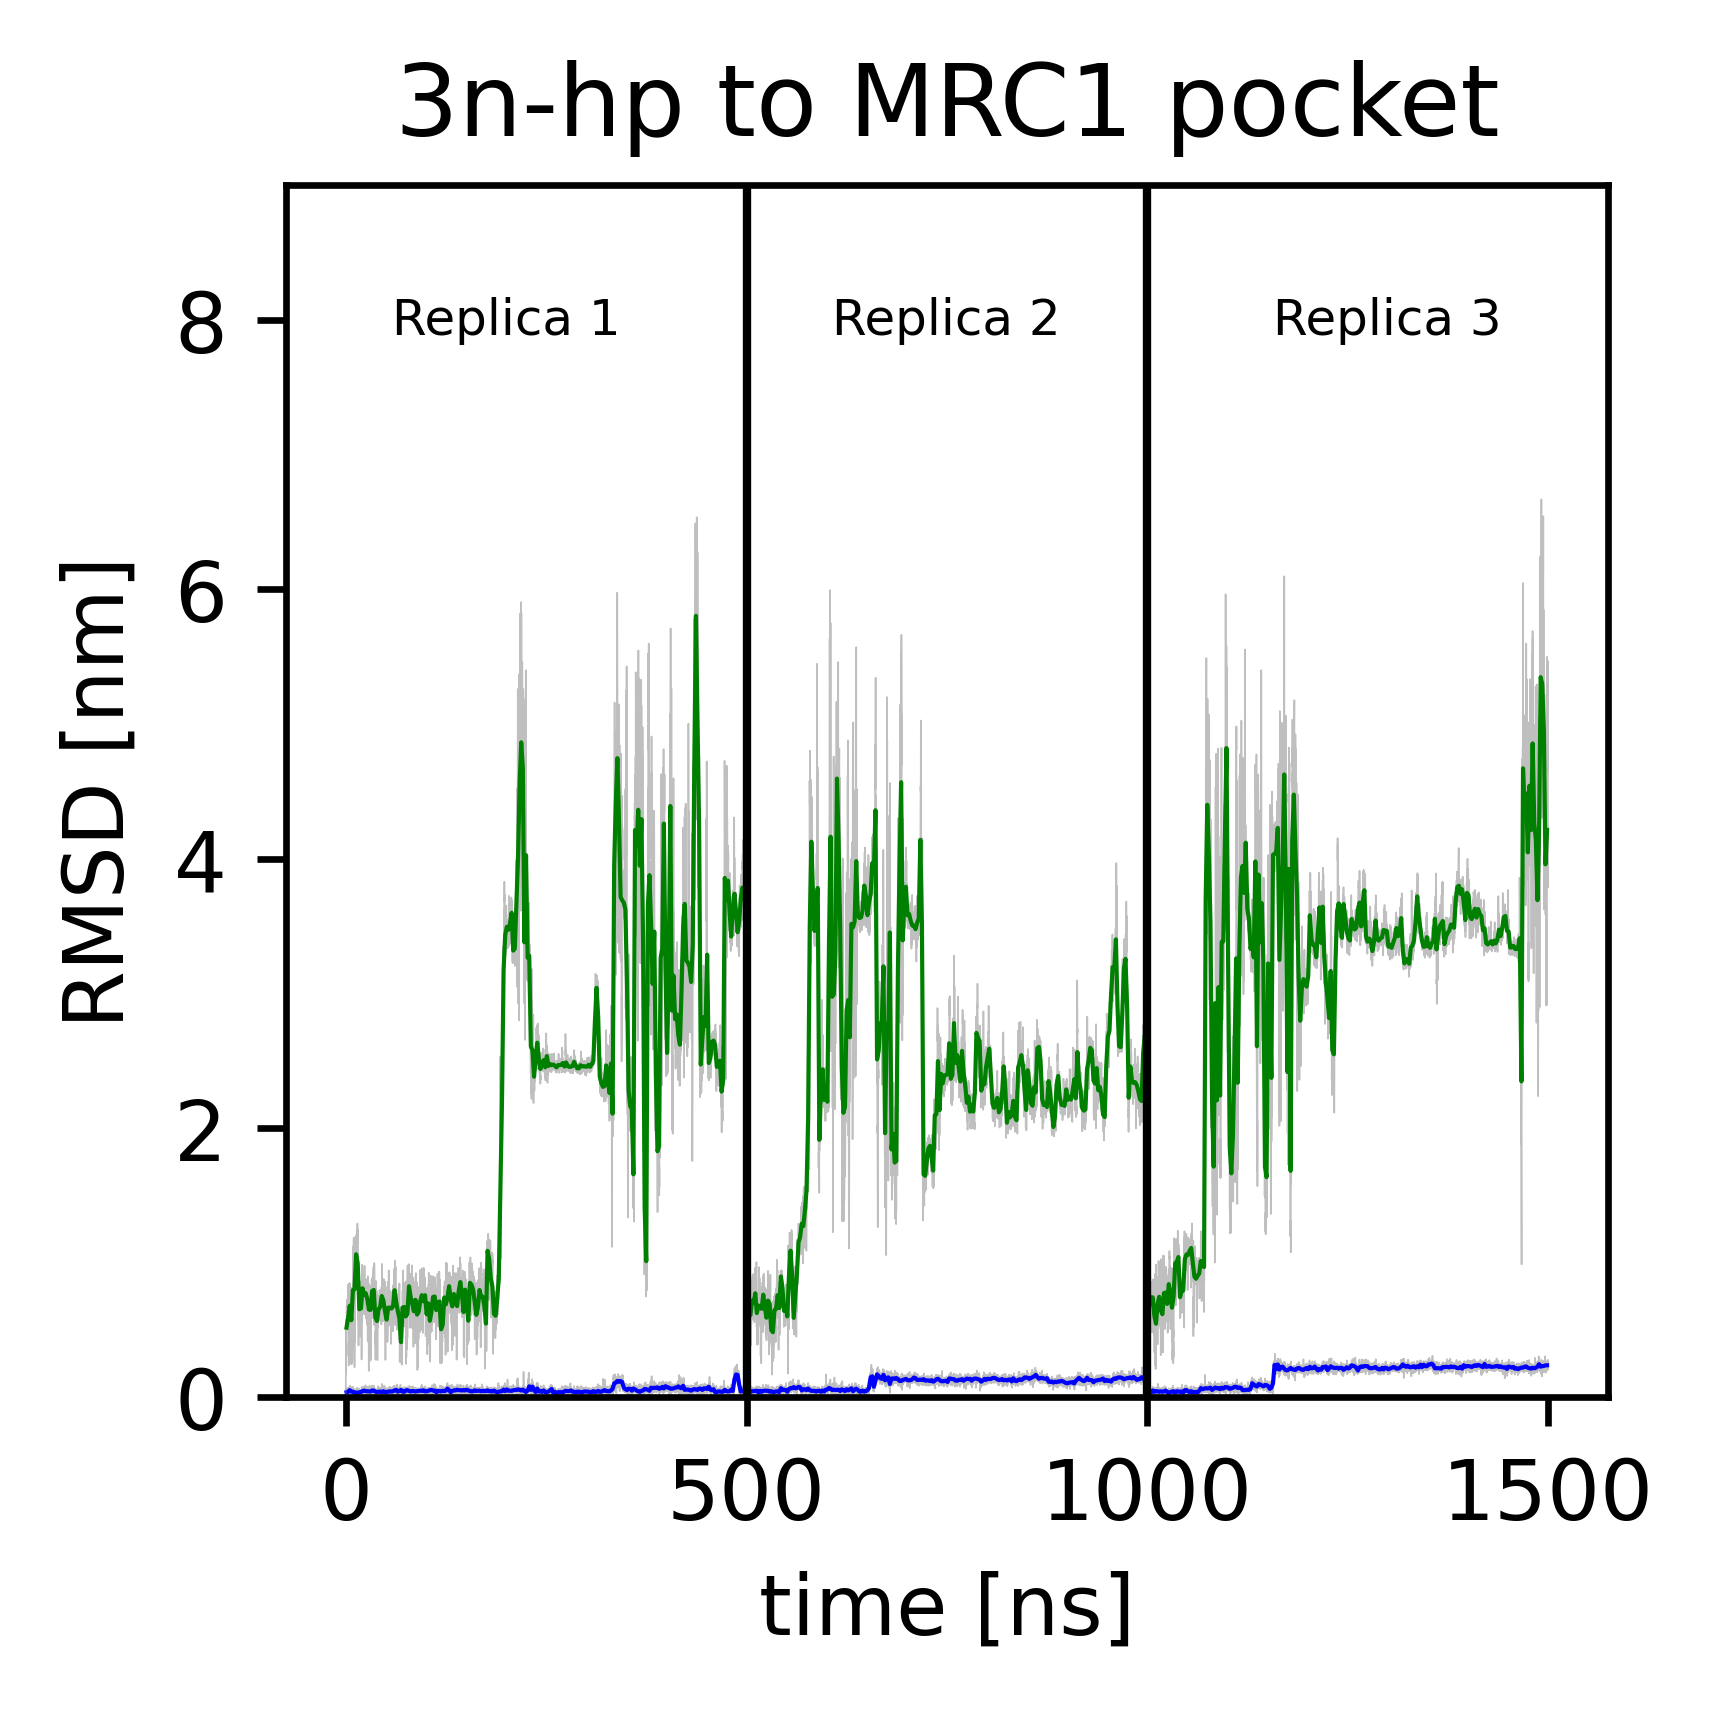

In [38]:
# plot RMSD
cm = 1/2.54
fig, ax = plt.subplots(figsize=(7.5*cm, 7.5*cm), dpi=600)

ax.plot(rmsd_cal_center.T[1], linewidth=0.2, c='grey', alpha=0.5)  # RMSD Cal
ax.plot(rmsd_cal_center[int(av/2-1):-int(av/2),0][::av]/1, rmean_cal[::av], linewidth=0.5, c='#0000FF') # smoothed RMSD Cal
ax.plot(rmsd_lig.T[1], linewidth=0.2, c='grey', alpha=0.5)  # RMSD lig
ax.plot(rmsd_lig[int(av/2-1):-int(av/2),0][::av]/1, rmean_lig[::av], linewidth=0.5, c='green') # smoothed RMSD lig
plt.axvline(5000, color='#000000', linewidth=1)  # borders between replica
plt.axvline(10000, color='#000000', linewidth=1)

plt.text(2000, 8, "Replica 1", size=6, rotation=0.,  # labels
         ha="center", va="center",
         bbox=dict(boxstyle="round",
                   ec=(1, 1, 1),
                   fc=(1,1,1),))
plt.text(7500, 8, "Replica 2", size=6, rotation=0.,
         ha="center", va="center",
         bbox=dict(boxstyle="round",
                   ec=(1, 1, 1),
                   fc=(1,1,1),))
plt.text(13000, 8, "Replica 3", size=6, rotation=0.,
         ha="center", va="center",
         bbox=dict(boxstyle="round",
                   ec=(1, 1, 1),
                   fc=(1,1,1),))

ax.set_ylim(0,9)
# ax.set_xlim(0,15010)
plt.xticks([0, 5000, 10000, 15000,], ['0', '500', '1000', '1500',], fontsize=10)
plt.title('3n-hp to MRC1 pocket')
ax.set_xlabel('time [ns]')
ax.set_ylabel('RMSD [nm]')
plt.tight_layout()
plt.savefig("/data/geissler/analysis/RMSD/cal_lig/3n-hp-mrc.png")

## different binding states

Here I define the different binding conformations ("binding states") by distances of different mannose Hydroxy-groups to different amino acids in the binding pocket of the receptor: 
<br> 
(the different HO-groups are hightlighted in Fig.5 of the paper)
- the "crystal state" is defined by HO4 being close to Glu725, HO3 being close to Glu733, HO6 being far away from Glu737 and HO2 being far away from Glu725
- "state A" is defined by HO2 being close to Glu725, HO4 being far from Glu725, HO6 being far from Glu737 and HO2 being far from Glu733
- "state B" is defined by HO2 being close to Glu733, HO4 being far from Glu725, HO6 being far from Glu737 and HO2 being far from Glu725
- "state C" is defined by HO6 being close to Glu737, HO3 being close to Glu733 and HO2 being far from Glu725 

In [3]:
# for the calculations I concatenated all frames of ligand being bound to the pocket
traj = mda.Universe(path_combined+'md_500ns.pdb',
                   path_combined+'combined_bound.xtc')

As I define the binding states by distances, I calculate the different distances between HO atoms and the respective amino acids

In [4]:
# this calculates the distance between the two defined atoms below for each frame of the simulation and appends them to a list
# distance 1: HO6 to Glutamic Acid 737
man = traj.select_atoms('resname LIG and name HO6')
prot = traj.select_atoms('protein and resid 737 and name CD') 

distance1 = []
R = np.zeros((man.atoms.n_atoms, prot.atoms.n_atoms))

for ts in traj.trajectory:
    dist_arr = distances.distance_array(man.positions,
                                       prot.positions,
                                       box=traj.dimensions,
                                       backend='OpenMP',
                                       result=R)
    distance1.append(dist_arr/10)  # convert from Angstr. to nm

In [5]:
# distance 2: HO2 to Glutamic Acid 725
man = traj.select_atoms('resname LIG and name HO2')
prot = traj.select_atoms('protein and resid 725 and name CD')

distance2 = []
R = np.zeros((man.atoms.n_atoms, prot.atoms.n_atoms))

for ts in traj.trajectory:
    dist_arr = distances.distance_array(man.positions,
                                       prot.positions,
                                       box=traj.dimensions,
                                       backend='OpenMP',
                                       result=R)
    distance2.append(dist_arr/10)  # convert from Angstr. to nm

In [6]:
# distance 3: HO3 to Glutamic Acid 733
man = traj.select_atoms('resname LIG and name HO3')
prot = traj.select_atoms('protein and resid 733 and name CD')

distance3 = []
R = np.zeros((man.atoms.n_atoms, prot.atoms.n_atoms))

for ts in traj.trajectory:
    dist_arr = distances.distance_array(man.positions,
                                       prot.positions,
                                       box=traj.dimensions,
                                       backend='OpenMP',
                                       result=R)
    distance3.append(dist_arr/10)  # convert from Angstr. to nm

In [7]:
# distance 4: HO4 to Glutamic Acid 725 
man = traj.select_atoms('resname LIG and name HO4')
prot = traj.select_atoms('protein and resid 725 and name CD')

distance4 = []
R = np.zeros((man.atoms.n_atoms, prot.atoms.n_atoms))

for ts in traj.trajectory:
    dist_arr = distances.distance_array(man.positions,
                                       prot.positions,
                                       box=traj.dimensions,
                                       backend='OpenMP',
                                       result=R)
    distance4.append(dist_arr/10)  # convert from Angstr. to nm

In [8]:
# distance 5: HO2 to Glutamic Acid 733
man = traj.select_atoms('resname LIG and name HO2')  
prot = traj.select_atoms('protein and resid 733 and name CD')

distance5 = []
R = np.zeros((man.atoms.n_atoms, prot.atoms.n_atoms))

for ts in traj.trajectory:
    dist_arr = distances.distance_array(man.positions,
                                       prot.positions,
                                       box=traj.dimensions,
                                       backend='OpenMP',
                                       result=R)
    distance5.append(dist_arr/10)  # convert from Angstr. to nm

In [9]:
# now I put them into 1 array
all_distances=np.column_stack((distance1,distance2,distance3,distance4,distance5))
# and make it flat
distances_flat=all_distances[:,:,0]
np.save('distances_flat.npy', distances_flat)

Now I sort the frames into their respective state. I defined the cutoff between close and far at 3.5 Ångström which roughliy corresponds to the length of a hydrogen bond.

In [10]:
# crystal state: HO4 close to Glu725, HO3 close to Glu733, HO6 far away from Glu737 and HO2 far away from Glu725
crystal = []
for i, j in enumerate(distances_flat):
    if distances_flat[i][3] <= 0.35 and distances_flat[i][2] <= 0.35 and distances_flat[i][0] > 0.35 and distances_flat[i][1] > 0.35:
        crystal.append(i)
print(len(crystal))  # print how many frames correspond to the crystal state

2220


In [11]:
# state A: HO2 close to Glu725, HO4 far from Glu725, HO6 far from Glu737 and HO2 far from Glu733
stateA = []
for i, j in enumerate(distances_flat):
    if distances_flat[i][1] <= 0.35 and distances_flat[i][3] > 0.35 and  distances_flat[i][0] > 0.35 and distances_flat[i][4] > 0.35:
        stateA.append(i)
print(len(stateA))

364


In [12]:
# state B: HO2 close to Glu733, HO4 far from Glu725, HO6 far from Glu737 and HO2 far from Glu725
stateB = []
for i, j in enumerate(distances_flat):
    if distances_flat[i][4] <= 0.35 and distances_flat[i][3] > 0.35 and distances_flat[i][0] > 0.35 and distances_flat[i][1] > 0.35:
        stateB.append(i)
print(len(stateB))

457


In [13]:
# state C: HO6 close to Glu737, HO3 close to Glu733 and HO2 far from Glu725
stateC = []
for i, j in enumerate(distances_flat):
    if distances_flat[i][0] <= 0.35 and distances_flat[i][2] <= 0.35 and distances_flat[i][1] > 0.35:
        stateC.append(i)
print(len(stateC))

0


In [14]:
# this is how I find out how many frames do not fall into any defined state ("others")
len(distances_flat)-len(crystal)-len(stateA)-len(stateB)-len(stateC)

232

## get frames of specific states to make a trajectory

For mmPBSA calculation for the specific states and for producing state contact maps, I will bin the frames of the same state together into one state specific trajectory. 
<br>
I will make trajectories between 100 and 300 frames, to have better comparability.
<br>
By multiplying the frame numbers with 100 ps and considering the order of replicas, I can use the output below directly as input for the 'states_trajectory.sh' bash script.

This is what the combined bound traj is made of:

- 1rep bound: 1931 frames, 193 ns, 193100 ps
- 2rep bound: 631 frames, 63 ns, 63100 ps
- 3rep bound: 711 frames, 71 ns, 71100 ps

  3273 frames in total -> 327300 ps

### crystal state

In [17]:
ps = 100
crystal_ps= [x*ps for x in crystal] 
print(*crystal_ps[:300])

0 100 200 300 400 500 600 700 800 900 1000 1100 1200 1300 1400 1500 2900 3000 3100 3200 3300 3400 3500 3600 3700 3800 3900 4000 4100 4200 4500 4600 4700 4800 4900 5000 5100 5200 5300 5400 5500 5600 5700 5800 5900 6000 6100 6200 6300 6400 6500 6600 6700 6800 6900 7000 7100 7200 7400 7600 7700 7800 7900 8100 8200 8300 8400 8500 8600 8700 8800 8900 9000 9100 9200 9300 9400 9500 9600 9700 9800 9900 10000 10100 10200 10300 10400 10500 10600 10700 10800 10900 11000 11100 11200 11300 11400 11500 11600 11700 11800 11900 12000 12100 12200 12400 12500 12600 12700 12800 12900 13000 13100 13200 13300 13400 13500 13600 13700 13800 13900 14000 14100 14200 14300 14400 14500 14600 14700 14800 14900 15000 15100 15200 15300 15400 15500 15600 15700 15800 15900 16000 16100 16200 16300 16400 16500 16600 16700 16800 16900 17000 17100 17200 17300 17400 17500 17600 17700 17800 17900 18000 18100 18200 18300 18400 18500 18600 18700 18800 18900 19000 19100 19200 19300 19400 19500 19600 19700 19800 19900 20000 20

The first 300 frames are all in replica 1.

### state A 

In [18]:
ps = 100
stateA_ps= [x*ps for x in stateA] 
print(*stateA_ps[:300])

246400 246600 247900 248000 248300 248400 249300 249500 250200 251000 251400 251500 252200 253200 253300 253400 253500 253600 253700 254200 289300 289400 289500 289600 289700 289800 289900 290000 290100 290200 290300 290400 290500 290600 290700 290800 290900 291000 291100 291200 291300 291400 291500 291600 291700 291800 291900 292000 292100 292200 292300 292400 292500 292700 292800 292900 293000 293100 293200 293300 293400 293500 293700 293800 293900 294000 294100 294200 294300 294400 294500 294600 294700 294800 294900 295000 295100 295200 295300 295400 295500 295600 295700 295800 295900 296000 296100 296200 296300 296400 296500 296600 296700 296800 296900 297000 297100 297200 297300 297500 297600 297700 297800 297900 298000 298100 298200 298300 298400 298500 298600 298700 298800 298900 299000 299100 299200 299300 299400 299500 299600 299700 299800 299900 300000 300100 300200 300300 300400 300500 300600 300700 300800 300900 301000 301200 301300 301400 301500 301600 301700 301800 301900

In [21]:
print('frames in 2rep:')
for i in stateA_ps[:500]:
    if i > 193100 and i <= (193100+63100):
        print(i-193100)

frames in 2rep:
53300
53500
54800
54900
55200
55300
56200
56400
57100
57900
58300
58400
59100
60100
60200
60300
60400
60500
60600
61100


In [22]:
print('frames in 3rep:')
for i in stateA_ps[:500]:
    if i > (193100+63100):
        print(i-(193100+63100))

frames in 3rep:
33100
33200
33300
33400
33500
33600
33700
33800
33900
34000
34100
34200
34300
34400
34500
34600
34700
34800
34900
35000
35100
35200
35300
35400
35500
35600
35700
35800
35900
36000
36100
36200
36300
36500
36600
36700
36800
36900
37000
37100
37200
37300
37500
37600
37700
37800
37900
38000
38100
38200
38300
38400
38500
38600
38700
38800
38900
39000
39100
39200
39300
39400
39500
39600
39700
39800
39900
40000
40100
40200
40300
40400
40500
40600
40700
40800
40900
41000
41100
41300
41400
41500
41600
41700
41800
41900
42000
42100
42200
42300
42400
42500
42600
42700
42800
42900
43000
43100
43200
43300
43400
43500
43600
43700
43800
43900
44000
44100
44200
44300
44400
44500
44600
44700
44800
45000
45100
45200
45300
45400
45500
45600
45700
45800
45900
46000
46100
46200
46300
46400
46500
46600
46700
46800
46900
47000
47100
47200
47300
47400
47500
47600
47700
47800
47900
48000
48100
48200
48300
48400
48500
48600
48700
48800
48900
49000
49100
49200
49300
49400
49500
49600
49700
49800


### state B

In [23]:
ps = 100
stateB_ps= [x*ps for x in stateB] 
print(*stateB_ps[:300])

2000 2300 4300 4400 7300 7500 8000 20100 20400 20500 20600 20800 20900 21000 21100 23400 25800 25900 26000 26100 26200 26400 26500 26600 26700 26800 26900 27000 27200 27400 28700 28800 28900 29000 29900 31300 32300 32400 32500 32600 32900 33000 33100 33200 33300 33400 33500 34700 35300 35400 37600 39200 47100 47200 59200 59800 60100 60600 62300 63600 64000 66900 67300 68600 68800 69600 70000 70200 71500 71600 75200 76300 77100 78400 78900 79000 80200 80300 80400 80500 80600 80900 81100 81400 82000 86100 86900 87000 87500 87600 92000 92200 92400 92700 92800 92900 93100 93200 95000 95100 96600 96700 96800 99500 102800 102900 103500 104100 106600 110100 110200 110300 110400 110500 110600 110700 111400 111500 111700 115100 115500 115700 115800 115900 116000 116100 116300 116500 116800 116900 117800 119100 119500 124700 124900 125600 125800 126200 126400 126500 126700 126800 126900 129000 129100 131300 131400 131500 131900 132000 132100 132200 132500 132600 132700 132800 132900 133500 13370

The first 300 frames are all in replica 1.

### state C has less than 100 frames